## BST 281 Final Project – Analysis Module 4

The purpose of this notebook is to cover the analyses proposed in module 4, which focus on identifying and prioritizing candidate ligands which may be major mediators of inflammatory signaling in the scRNA-seq dataset generated by Bellissimo *et al.* in murine Runx1 KO hematopoietic progenitors.

Previously, we generated a list of genes differentially expressed in each annotated cell tpe between Runx1 KO and WT genotypes using edgeR after performing normalization, filtering, and clustering. These gene sets will be used for this analysis.

The main tool used for this analysis will be NicheNet, which ranks ligands by how well their predicted target genes match the observed transcriptional prgoram in a receiver cell population. The main ranking metrics are AUROC, AUPR, and Spearman correlation.

### Analysis 1
**Objective:** Assess differential expression of ligands which are likely to be responsible for the dysregulated inflammatory transcriptional programs in Runx1 KO progenitor populations.<br>
**Question:** Which cytokines/ligands are most likely to drive inflammatory signaling in RUNX1-FPD based on the transcriptional signatures of hematopoietic subpopulations, in which subpopulations are they produced, and to whom do they signal? <br>
**Methods:** Using the publicly available NicheNet tool (https://www.nature.com/articles/s41592-019-0667-5) treating each individual hematopoietic cluster as a separate receiver population and integrating with our previously generated list of DEGs.<br>
**Output:** A ranked ligand list ranked by enrichment score(?) and a heatmap of top "guilty-by-association" hits by AUROC and AUPR across receiver subpopulations.

*1. Set up R environment*

In [22]:
# Load packages
library(nichenetr)
library(Seurat)
library(tidyverse)
library(pheatmap)

*2. Load previous Seurat object from Module 1*

In [23]:
runx1_obj <- readRDS("/Users/fionareed/Desktop/BST281/final_project/GSE144482/GSE144482_Runx1_LSK_reclustered_FR.rds")
print(runx1_obj)


An object of class Seurat 
17859 features across 14795 samples within 1 assay 
Active assay: RNA (17859 features, 0 variable features)
 1 layer present: counts


In [24]:

# Re-assign metadata columns
Idents(runx1_obj) <- runx1_obj@meta.data[['matched_ctype_refined']]

*3. Load open-source NicheNet networks for analysis*

In [25]:
organism <- "mouse"

lr_network <- readRDS(
  "/Users/fionareed/Desktop/BST281/final_project/lr_network_mouse_21122021.rds"
) 

ligand_target_matrix <- readRDS(
 "/Users/fionareed/Desktop/BST281/final_project/ligand_target_matrix_nsga2r_final_mouse.rds"
) 

weighted_networks <- readRDS(
  "/Users/fionareed/Desktop/BST281/final_project/weighted_networks_nsga2r_final_mouse.rds"
)

lr_network <- lr_network %>% 
  distinct(from, to)

In [26]:
head(lr_network) # inspect loaded network
print(paste0("Number of ligands: ", length(unique(lr_network$from))))
print(paste0("Number of receptors: ", length(unique(lr_network$to))))

from,to
<chr>,<chr>
2300002M23Rik,Ddr1
2610528A11Rik,Gpr15
9530003J23Rik,Itgal
a,Atrn
a,F11r
a,Mc1r


[1] "Number of ligands: 1287"
[1] "Number of receptors: 1084"


*4. Load and inspect edgeR DEG tables*

In [27]:
proj_dir <- ("/Users/fionareed/Desktop/BST281/final_project/GSE144482/edgeR_results_by_celltype")

load_edgeR <- function(ct) { # write function to load in edgeR results
  file_path <- file.path(proj_dir, paste0("edgeR_results_", ct, ".csv"))
  if (file.exists(file_path)) {
    return(read.csv(file_path))
  } else {
    warning(paste("File not found for cell type:", ct))
    return(NULL)
  }
}


In [28]:

celltypes_load <- c("C1qb", "Car1", "Ccl5", "CD34", "Cd74", "Fcnb", "Gstm1_CD63",
    "Gstm1_Ly86", "Hba-a2", "Ltf", "Ly86", "Pf4", "Prg2", "Siglech", "Vpreb1")

edgeR_list <- lapply(celltypes_load, load_edgeR)
names(edgeR_list) <- celltypes_load

head(edgeR_list$C1qb) # check loaded tables

,logFC,logCPM,PValue,FDR,gene,celltype,bcv,dispersion
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,5.170742,13.708635,3.101103e-24,2.044093e-20,Lyz2,C1qb,0.2,0.04
2,-11.377613,11.133187,3.918515e-24,2.044093e-20,Cxcl12,C1qb,0.2,0.04
3,6.309469,10.817311,3.900806e-21,1.356570e-17,Cd52,C1qb,0.2,0.04
4,7.643607,10.283033,3.894839e-20,1.015871e-16,Ifi27l2a,C1qb,0.2,0.04
5,-10.499959,10.287932,1.777353e-18,3.708626e-15,Mgp,C1qb,0.2,0.04
6,5.614076,9.727175,2.500937e-14,4.348713e-11,Chil3,C1qb,0.2,0.04


*5. Define differentially expressed genes from each cluster*

In [29]:
# write function to define receiver genes for each cluster
define_receiver_genes <- function(cluster, gene_list, fdr, logfc) {
    deg_df <- gene_list[[cluster]]

    genes <- deg_df %>%
        filter(FDR < fdr, abs(logFC) > logfc) %>%
        pull(gene)

    genes
}

*Use previously defined cutoffs: FDR < 0.05, abs(LogFC) > 1*

In [30]:
receiver_genes <- list()

for (i in 1:length(celltypes_load)) {
    ct <- celltypes_load[i]
    genes <- define_receiver_genes(ct, edgeR_list, fdr = 0.05, logfc = 1)
    receiver_genes[[ct]] <- genes
}

*6. Keep only genes present in the NicheNet ligand-target matrix*

In [31]:
receiver_genes_present <- list() 

for (i in 1:length(celltypes_load)) {
    ct <- celltypes_load[i]
   present <- receiver_genes[[ct]] %>%
        intersect(rownames(ligand_target_matrix)
    )
    receiver_genes_present[[ct]] <- present
    }

sapply(receiver_genes_present, length) # Check output

C1qb       Car1       Ccl5       CD34       Cd74       Fcnb Gstm1_CD63 
       129        538          8        326         33         29        171 
Gstm1_Ly86     Hba-a2        Ltf       Ly86        Pf4       Prg2    Siglech 
        68        186         13        318        171          5          6 
    Vpreb1 
        15

*7. Define all of the expressed genes (not just differentially expressed genes) in the receiver cluster directly from Seurat object to create the background universe for NicheNet to compare to*

In [32]:
# First I need to subset the Seurat object just to the Runx1 KO dataset
runx1_obj_ko <- subset(
  runx1_obj,
  subset = Dataset == "Dana_KO"
)
runx1_obj_ko

An object of class Seurat 
17859 features across 7889 samples within 1 assay 
Active assay: RNA (17859 features, 0 variable features)
 1 layer present: counts

In [33]:
# First get the repertoire of all expressed genes
# For some reason I couldn't get this to work in a function, oh well
expr_c1qb <- get_expressed_genes("C1qb", runx1_obj_ko, 0.05)
expr_car1 <- get_expressed_genes("Car1", runx1_obj_ko, 0.05)
expr_ccl5 <- get_expressed_genes("Ccl5", runx1_obj_ko, 0.05)
expr_cd34 <- get_expressed_genes("CD34", runx1_obj_ko, 0.05) 
expr_cd74 <- get_expressed_genes("Cd74", runx1_obj_ko, 0.05)
expr_fcnb <- get_expressed_genes("Fcnb", runx1_obj_ko, 0.05)
expr_gstm1_cd63 <- get_expressed_genes("Gstm1/CD63", runx1_obj_ko, 0.05)
expr_gstm1_ly86 <- get_expressed_genes("Gstm1/Ly86", runx1_obj_ko, 0.05)
expr_hbaa2 <- get_expressed_genes("Hba-a2", runx1_obj_ko, 0.05) 
expr_ltf <- get_expressed_genes("Ltf", runx1_obj_ko, 0.05) 
expr_ly86 <- get_expressed_genes("Ly86", runx1_obj_ko, 0.05)
expr_pf4 <- get_expressed_genes("Pf4", runx1_obj_ko, 0.05) 
expr_prg2 <- get_expressed_genes("Prg2", runx1_obj_ko, 0.05) 
expr_siglech <- get_expressed_genes("Siglech", runx1_obj_ko, 0.05) 
expr_vpreb1 <- get_expressed_genes("Vpreb1", runx1_obj_ko, 0.05)

# Compile into one list of all expressed genes
expressed_genes_all <- list(
  expr_c1qb,
  expr_car1,
  expr_ccl5,
  expr_cd34,
  expr_cd74,
  expr_fcnb,
  expr_gstm1_cd63,
  expr_gstm1_ly86,
  expr_hbaa2,
  expr_ltf,
  expr_ly86,
  expr_pf4,
  expr_prg2,
  expr_siglech,
  expr_vpreb1
) %>%
  unlist() %>%
  unique()

# Then define the background based on overlap with NicheNet's matrix
bg_c1qb <- expr_c1qb %>% intersect(rownames(ligand_target_matrix))
bg_car1 <- expr_car1 %>% intersect(rownames(ligand_target_matrix))
bg_ccl5 <- expr_ccl5 %>% intersect(rownames(ligand_target_matrix))
bg_cd34 <- expr_cd34 %>% intersect(rownames(ligand_target_matrix))
bg_cd74 <- expr_cd74 %>% intersect(rownames(ligand_target_matrix))
bg_fcnb <- expr_fcnb %>% intersect(rownames(ligand_target_matrix))
bg_gstm1_cd63 <- expr_gstm1_cd63 %>% intersect(rownames(ligand_target_matrix))
bg_gstm1_ly86 <- expr_gstm1_ly86 %>% intersect(rownames(ligand_target_matrix))
bg_hbaa2 <- expr_hbaa2 %>% intersect(rownames(ligand_target_matrix))
bg_ltf <- expr_ltf %>% intersect(rownames(ligand_target_matrix))
bg_ly86 <- expr_ly86 %>% intersect(rownames(ligand_target_matrix))
bg_pf4 <- expr_pf4 %>% intersect(rownames(ligand_target_matrix))
bg_prg2 <- expr_prg2 %>% intersect(rownames(ligand_target_matrix))
bg_siglech <- expr_siglech %>% intersect(rownames(ligand_target_matrix))
bg_vpreb1 <- expr_vpreb1 %>% intersect(rownames(ligand_target_matrix))

# Convert this to a list 
bg_genes <- list(
  C1qb = bg_c1qb,
  Car1 = bg_car1,
  Ccl5 = bg_ccl5,
  CD34 = bg_cd34,
  Cd74 = bg_cd74,
  Fcnb = bg_fcnb,
  Gstm1_CD63 = bg_gstm1_cd63,
  Gstm1_Ly86 = bg_gstm1_ly86,
  Hba_a2 = bg_hbaa2,
  Ltf = bg_ltf,
  Ly86 = bg_ly86,
  Pf4 = bg_pf4,
  Prg2 = bg_prg2,
  Siglech = bg_siglech,
  Vpreb1 = bg_vpreb1
)

Warning message in GetAssayData.StdAssay(object = object[[assay]], layer = layer):
“data layer is not found and counts layer is used”
Warning message in GetAssayData.StdAssay(object = object[[assay]], layer = layer):
“data layer is not found and counts layer is used”
Warning message in GetAssayData.StdAssay(object = object[[assay]], layer = layer):
“data layer is not found and counts layer is used”
Warning message in GetAssayData.StdAssay(object = object[[assay]], layer = layer):
“data layer is not found and counts layer is used”
Warning message in GetAssayData.StdAssay(object = object[[assay]], layer = layer):
“data layer is not found and counts layer is used”
Warning message in GetAssayData.StdAssay(object = object[[assay]], layer = layer):
“data layer is not found and counts layer is used”
Warning message in GetAssayData.StdAssay(object = object[[assay]], layer = layer):
“data layer is not found and counts layer is used”
Warning message in GetAssayData.StdAssay(object = object[[assa

*8. Define receptors expressed by the receiver cluster*

In [34]:
all_receptors <- unique(lr_network$to)

# I did use generative AI to automate writing this
expr_receptors_c1qb <- expr_c1qb %>% intersect(all_receptors)
expr_receptors_car1 <- expr_car1 %>% intersect(all_receptors)
expr_receptors_ccl5 <- expr_ccl5 %>% intersect(all_receptors)
expr_receptors_cd34 <- expr_cd34 %>% intersect(all_receptors)
expr_receptors_cd74 <- expr_cd74 %>% intersect(all_receptors)
expr_receptors_fcnb <- expr_fcnb %>% intersect(all_receptors)
expr_receptors_gstm1_cd63 <- expr_gstm1_cd63 %>% intersect(all_receptors)
expr_receptors_gstm1_ly86 <- expr_gstm1_ly86 %>% intersect(all_receptors)
expr_receptors_hbaa2 <- expr_hbaa2 %>% intersect(all_receptors)
expr_receptors_ltf <- expr_ltf %>% intersect(all_receptors)
expr_receptors_ly86 <- expr_ly86 %>% intersect(all_receptors)
expr_receptors_pf4 <- expr_pf4 %>% intersect(all_receptors)
expr_receptors_prg2 <- expr_prg2 %>% intersect(all_receptors)
expr_receptors_siglech <- expr_siglech %>% intersect(all_receptors)
expr_receptors_vpreb1 <- expr_vpreb1 %>% intersect(all_receptors)

# And then also combine this into one list to get the full repertoire of receptors across all cell types
expressed_receptors_all <- list(
  expr_receptors_c1qb,
  expr_receptors_car1,
  expr_receptors_ccl5,
  expr_receptors_cd34,
  expr_receptors_cd74,
  expr_receptors_fcnb,
  expr_receptors_gstm1_cd63,
  expr_receptors_gstm1_ly86,
  expr_receptors_hbaa2,
  expr_receptors_ltf,
  expr_receptors_ly86,
  expr_receptors_pf4,
  expr_receptors_prg2,
  expr_receptors_siglech,
  expr_receptors_vpreb1
) %>%
  unlist() %>%
  unique()

length(expressed_receptors_all)

[1] 522

*9. Define all possible sender clusters. For my initial analysis, I will be population-agnostic and simply interrogate all possible clusters as potential sender populations.*

In [35]:
sender_clusters <- celltypes_load
sender_clusters

[1] "C1qb"       "Car1"       "Ccl5"       "CD34"       "Cd74"      
 [6] "Fcnb"       "Gstm1_CD63" "Gstm1_Ly86" "Hba-a2"     "Ltf"       
[11] "Ly86"       "Pf4"        "Prg2"       "Siglech"    "Vpreb1"

*10. Next, what I would do is get genes expressed by each sender cluster. Since this analysis is sender population-agnostic, we've actually already done this above. We still need to get a list of all expressed genes for n-1 sender clusters to test with our populations of interest, so I will do that here.*

In [36]:
# Define list of all expression clusters
expr_list <- list(
  c1qb = expr_c1qb,
  car1 = expr_car1,
  ccl5 = expr_ccl5,
  cd34 = expr_cd34,
  cd74 = expr_cd74,
  fcnb = expr_fcnb,
  gstm1_cd63 = expr_gstm1_cd63,
  gstm1_ly86 = expr_gstm1_ly86,
  hbaa2 = expr_hbaa2,
  ltf = expr_ltf,
  ly86 = expr_ly86,
  pf4 = expr_pf4,
  prg2 = expr_prg2,
  siglech = expr_siglech,
  vpreb1 = expr_vpreb1
)

# Define the n-1 function

make_n_minus_1_gene_lists <- function(expr_list) {
  
  dropout_lists <- lapply(names(expr_list), function(dropout_ct) {
    
    expr_list[names(expr_list) != dropout_ct] %>%
      unlist() %>%
      unique()
  })
  
  names(dropout_lists) <- paste0("minus_", names(expr_list))
  
  return(dropout_lists)
}

In [37]:
expressed_genes_senders_minus_one <- make_n_minus_1_gene_lists(expr_list)

# Check 
length(expressed_genes_senders_minus_one$minus_pf4)
length(expressed_genes_senders_minus_one$minus_c1qb)

[1] 12212

[1] 12123

*11. Define ligand candidates. To be a ligand candidate, it must be 1) expressed by any sender population AND 2) have its receptor expressed in the tested receiver population.*

In [38]:
# Test ligands with expressed receptors in any cell receiver population
ligands_with_expressed_receptors <- lr_network %>%
  filter(to %in% expressed_receptors_all) %>%
  pull(from) %>%
  unique()
length(ligands_with_expressed_receptors)

# Obtain candidate ligands which are expressed in senders
candidate_ligands <- expressed_genes_all %>%
  intersect(ligands_with_expressed_receptors) %>%
  intersect(colnames(ligand_target_matrix))
length(candidate_ligands)

[1] 1073

[1] 402

*Based on this analysis, there are 402 candidate ligands that are both expressed in at least one sender population in the Runx1 KO progenitors from the dataset, and which have their receptor expressed in at least one receiver population. These are the candidates that NicheNet will test.* 

*12. Run NicheNet ligand activity analysis for one cluster at first, as a test*

In [39]:
ligand_activities_c1qb <- predict_ligand_activities(
    geneset = receiver_genes_present$C1qb,
    background_expressed_genes = bg_c1qb,
    ligand_target_matrix = ligand_target_matrix,
    potential_ligands = candidate_ligands)

In [40]:
# Rank and inspect output
ligand_activities_c1qb <- ligand_activities_c1qb %>%
    arrange(desc(aupr_corrected)) %>%
    mutate(rank = row_number())

head(ligand_activities_c1qb, 20)

test_ligand,auroc,aupr,aupr_corrected,pearson,rank
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Tgfb1,0.7329213,0.08616619,0.06828925,0.17001961,1
Il4,0.7529963,0.07828291,0.06040597,0.17083259,2
Tnf,0.7696126,0.07214725,0.05427031,0.15267043,3
Bmp7,0.6811976,0.06843193,0.05055499,0.12888878,4
Sparc,0.6955923,0.06537752,0.04750058,0.07607604,5
B2m,0.6794212,0.06537081,0.04749387,0.13472287,6
Nrp1,0.6868242,0.06252413,0.04464719,0.14402518,7
Csf1,0.7374311,0.06092610,0.04304916,0.13464205,8
Ang,0.7242757,0.06014840,0.04227146,0.11111050,9


According to NicheNet's documentation, a reasonable AUROC begins around 0.6, with 0.7-0.8 representingn strong signal and >0.8 being unexpectedly high for scRNA-seq data. In their official vignette example, the top interferon ligands have AUROC 0.68-0.71, which are top hits. They also discern that biologically meaningful results may come from a corrected AUPR in a heterogeneous population with few query genes for 0.01-0.10. The Pearson correlation is almost somewhat weak for many of these but again, it's a heterogeneous dataset with very few DEGs. Most of these scores are relatively modest but biologically plausible. 

Ultimately, candidate upstream ligands were ranked by NicheNet ligand activity, using corrected AUPR as the primary metric because it best captures enrichment of predicted ligand targets within the receiver transcriptional response. Ligands were further prioritized if they were upregulated in Runx1 KO sender populations and had cognate receptors expressed in the receiver population.

In [41]:
# Save ranked lsit
write.csv(
  ligand_activities_c1qb,
  file = paste0("NicheNet_ranked_ligands_receiver_C1qb.csv"),
  row.names = FALSE
)

# Select top ligands
top_n_ligands_c1qb <- 30

top_n_ligands_c1qb <- ligand_activities_c1qb %>%
  slice_head(n = top_n_ligands_c1qb) %>%
  pull(test_ligand)

top_n_ligands_c1qb


[1] "Tgfb1"   "Il4"     "Tnf"     "Bmp7"    "Sparc"   "B2m"     "Nrp1"   
 [8] "Csf1"    "Ang"     "Bgn"     "Ccl25"   "Pf4"     "Hp"      "Ccl3"   
[15] "Adam17"  "Cd33"    "Nrg3"    "Angptl3" "Mag"     "C1qb"    "Vegfa"  
[22] "Anxa2"   "Cd300c2" "Cd300c"  "Mpdz"    "Ltbp1"   "Nrg2"    "Saraf"  
[29] "Qrfp"    "Cd55"

*13. Create heatmap of top candidate ligands driving transcriptional profiles in C1qb*

Loading required package: viridisLite

Warning message:
“package ‘viridisLite’ was built under R version 4.5.2”


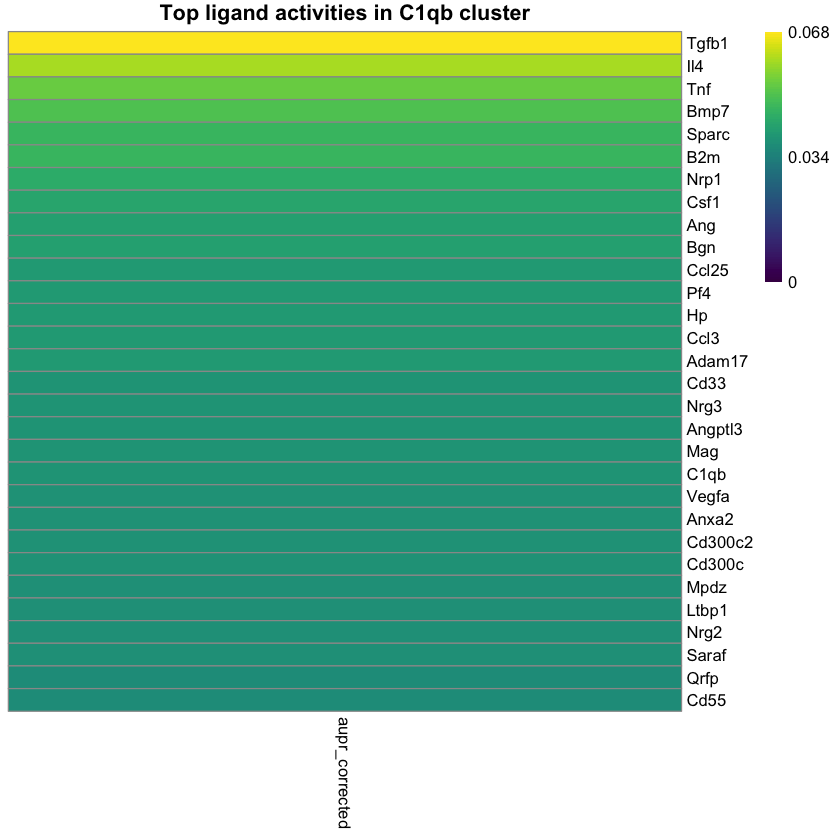

In [42]:
library(viridis)

ligand_activity_mat_c1qb <- ligand_activities_c1qb %>%
  filter(test_ligand %in% top_n_ligands_c1qb) %>%
  select(test_ligand, aupr_corrected) %>%
  column_to_rownames("test_ligand") %>%
  arrange(desc(aupr_corrected)) %>%
  as.matrix()

# Define max score for plotting purposes
max_score <- max(ligand_activity_mat_c1qb[, "aupr_corrected"], na.rm = TRUE)
my_colors <- viridis(100, direction = 1)
my_breaks <- seq(0, max_score, length.out = 101)

pheatmap(
  ligand_activity_mat_c1qb,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = my_colors,
  breaks = my_breaks,
  main = paste0("Top ligand activities in C1qb cluster"), 
  legend = TRUE,
  legend_breaks = c(0, max_score / 2, max_score),
  legend_labels = round(c(0, max_score / 2, max_score), 3))

*14. Plot top ligand expression across sender populations to determine source of signaling*

In [43]:
# First we need to calculate expression by genotype
avg_expr <- AggregateExpression(
    runx1_obj_ko,
    group.by = "matched_ctype_refined"
)$RNA


[1] "C1qb"       "Car1"       "Ccl5"       "CD34"       "Cd74"      
 [6] "Fcnb"       "Gstm1/CD63" "Gstm1/Ly86" "Hba-a2"     "Ltf"

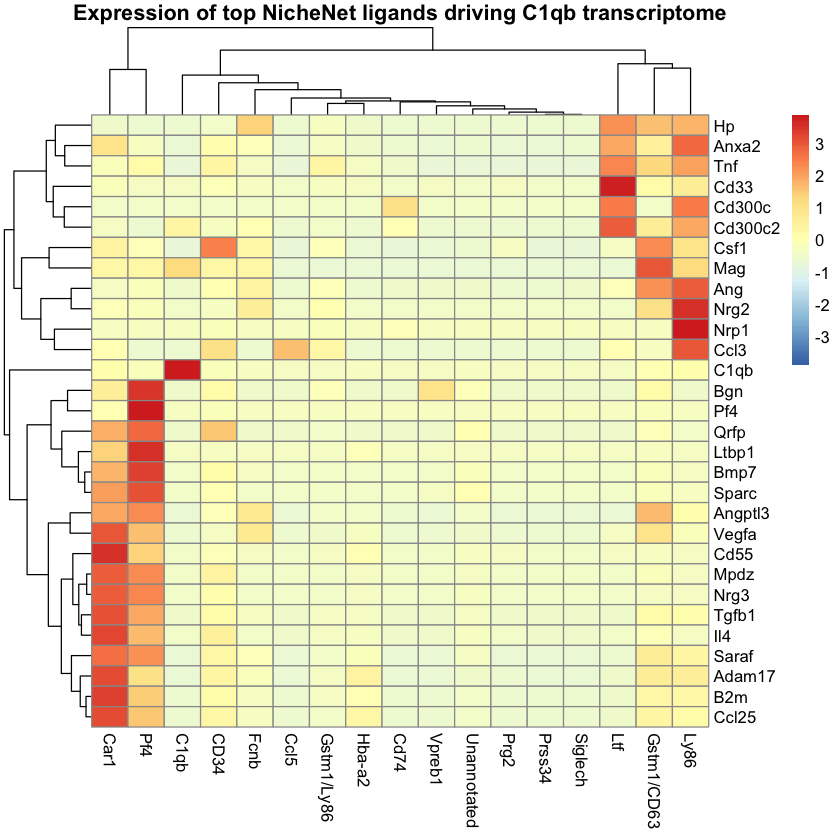

In [49]:
# Check column names
colnames(avg_expr)[1:10]

# Subset to top ligands
top_ligand_expr <- avg_expr[
  rownames(avg_expr) %in% top_n_ligands_c1qb,
  ,
  drop = FALSE
]

# Draw an expression heatmap in each sender cell type
pheatmap(
  top_ligand_expr,
  scale = "row",
  main = paste0("Expression of top NicheNet ligands driving C1qb transcriptome")
)

This heatmap tells us: Among Runx1 KO cells only, which sender clusters express each top ligand most highly? This is useful for telling us which cell types are a likely source of the top ligands. 

*15. Calculate logFC of top ligands across sender populations*

,gene,logFC,FDR,cluster
,<chr>,<dbl>,<dbl>,<chr>
1,Bgn,-9.086581,8.977160e-08,C1qb
2,Hp,-3.966508,1.927110e-06,C1qb
3,Pf4,4.341880,2.519316e-05,C1qb
4,Sparc,-8.420717,3.424204e-05,C1qb
5,C1qb,2.474747,5.175245e-04,C1qb
6,Cd300c2,3.775223,1.623781e-03,C1qb


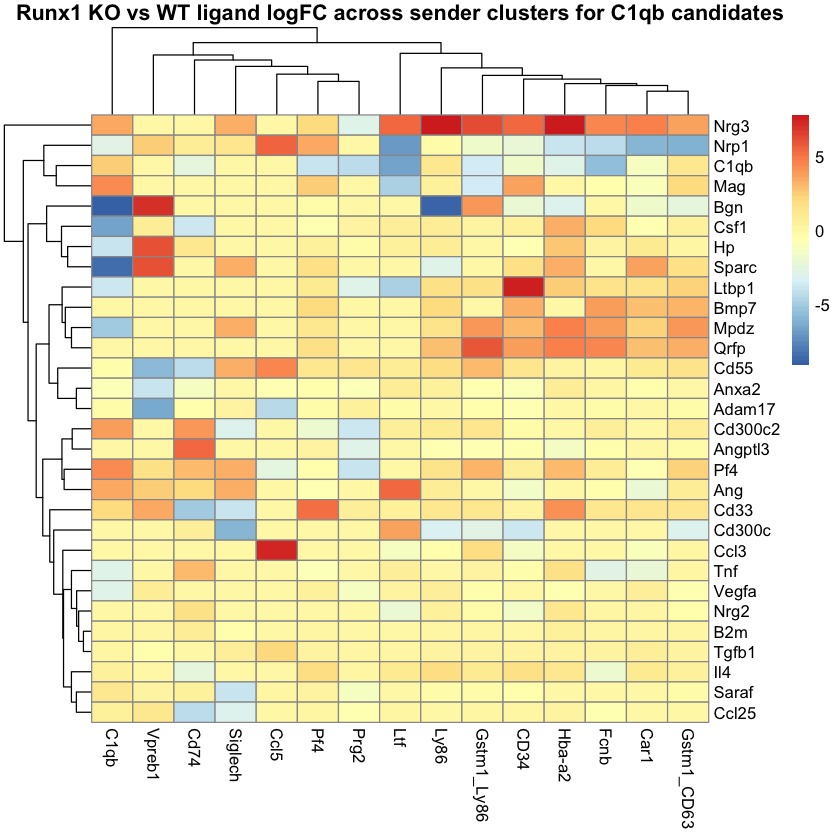

In [50]:
# Define a function
ligand_logfc_by_cluster <- map_dfr(celltypes_load, function(cluster_name) {
  
  edgeR_list[[cluster_name]] %>%
    filter(gene %in% top_n_ligands_c1qb) %>%
    select(gene, logFC, FDR) %>%
    mutate(cluster = cluster_name)
})

head(ligand_logfc_by_cluster) # Check result

# Convert to a format which is plottable by heatmap
ligand_logfc_mat <- ligand_logfc_by_cluster %>%
  select(gene, cluster, logFC) %>%
  pivot_wider(
    names_from = cluster,
    values_from = logFC,
    values_fill = 0
  ) %>%
  column_to_rownames("gene") %>%
  as.matrix()

  # Plot the heatmap
  pheatmap(
  ligand_logfc_mat,
  main = paste0("Runx1 KO vs WT ligand logFC across sender clusters for C1qb candidates"),
  cluster_rows = TRUE,
  cluster_cols = TRUE
)

Within each sender cluster, which ligands are higher or lower in Runx1 KO compared with WT? This is useful for telling us which ligands are most unique to the Runx1 KO genotpe.

*16. Predict target genes in the receiver regulated by each top ligand*

In [51]:
ligand_target_links_df_c1qb <- top_n_ligands_c1qb %>%
  lapply(function(ligand) {
    get_weighted_ligand_target_links(
      ligand = ligand,
      geneset = receiver_genes_present$C1qb,
      ligand_target_matrix = ligand_target_matrix,
      n = 100
    )
  }) %>%
  bind_rows() %>%
  drop_na()

head(ligand_target_links_df_c1qb)

ligand,target,weight
<chr>,<chr>,<dbl>
Tgfb1,Angptl4,0.2977012
Tgfb1,Col4a1,0.2411745
Tgfb1,Id3,0.2941962
Tgfb1,Junb,0.2858194
Tgfb1,Serpine2,0.2596184
Tgfb1,Sox4,0.2759580


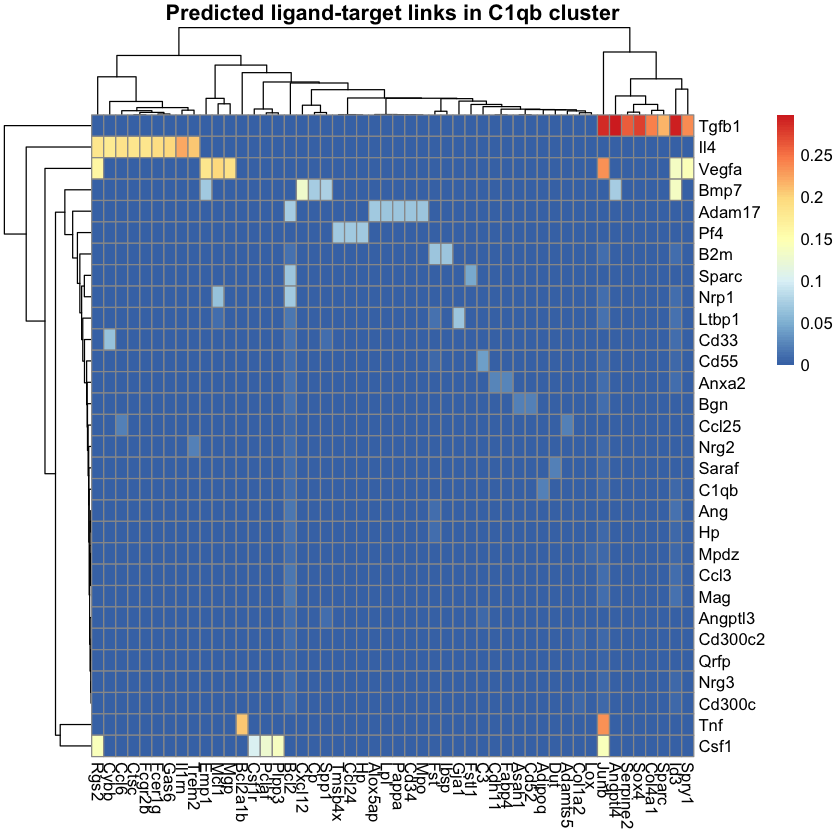

In [52]:
# Plot the heatmap for ligand-gene associations
active_targets_c1qb <- ligand_target_links_df_c1qb %>%
  group_by(target) %>%
  summarise(max_weight = max(weight, na.rm = TRUE)) %>%
  arrange(desc(max_weight)) %>%
  slice_head(n = 50) %>%
  pull(target)

ligand_target_mat_c1qb <- ligand_target_links_df_c1qb %>%
  filter(target %in% active_targets_c1qb) %>%
  select(ligand, target, weight) %>%
  pivot_wider(
    names_from = target,
    values_from = weight,
    values_fill = 0
  ) %>%
  column_to_rownames("ligand") %>%
  as.matrix()

pheatmap(
  ligand_target_mat_c1qb,
  main = paste0("Predicted ligand-target links in C1qb cluster"),
  cluster_rows = TRUE,
  cluster_cols = TRUE
)

The purpose of this figure is to tell us which receiver program genes are predicted targets of each prioritized ligand

*18. Run NicheNet across all cell clusters/receivers populations*

In [53]:
# Create output directories
dir.create("/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs")
dir.create("/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs/csv")
dir.create("/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs/heatmaps")

# deal with funky filenames
make_safe_name <- function(x) { 
  x %>%
    as.character() %>%
    gsub("[^A-Za-z0-9_]+", "_", .) %>%
    gsub("_+", "_", .) %>%
    gsub("^_|_$", "", .)
}

Warning message in dir.create("/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs"):
“'/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs' already exists”
Warning message in dir.create("/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs/csv"):
“'/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs/csv' already exists”
Warning message in dir.create("/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs/heatmaps"):
“'/Users/fionareed/Desktop/BST281/final_project/GSE144482/NicheNet_outputs/heatmaps' already exists”


In [72]:
# Define a NicheNet function which can take all of the populations
run_nichenet_receiver <- function(receiver,
    receiver_genes_present, bg_genes, ligand_target_matrix, candidate_ligands,
    runx1_obj_ko, edgeR_list, celltypes_load, group_col = "matched_ctype_refined",
    top_n_ligands = 30, n_target_links = 100, n_active_targets = 50,
    output_dir = "NicheNet_outputs") {
  
  message("Running NicheNet for receiver cluster: ", receiver)
  
  safe_receiver <- make_safe_name(receiver)

  # Get receiver genes and background genes for receiver cluster
  geneset_oi <- receiver_genes_present[[receiver]]
  background_genes <- bg_genes[[receiver]]

  if (length(geneset_oi) < 10) {
    warning("Skipping ", receiver, ": fewer than 10 receiver genes present in ligand-target matrix.")
    return(NULL)
  }
  
  if (length(background_genes) < 100) {
    warning("Skipping ", receiver, ": fewer than 100 background genes present in ligand-target matrix.")
    return(NULL)
  }

  # Run NicheNet's ligand activity analysis tool
  ligand_activities <- predict_ligand_activities(
    geneset = geneset_oi, background_expressed_genes = background_genes,
    ligand_target_matrix = ligand_target_matrix, potential_ligands = candidate_ligands
  ) %>% 
    arrange(desc(aupr_corrected)) %>%
    mutate(
        rank = row_number(),
        receiver = receiver
    )
 # Save ranked ligand list
 write.csv(ligand_activities, file = file.path(output_dir, "csv", paste0("NicheNet_ranked_ligands_receiver_", 
    safe_receiver, ".csv") ), row.names = FALSE
  )

 # Select the top ligands
top_ligands <- ligand_activities %>%
  arrange(desc(aupr_corrected)) %>%
  pull(test_ligand)

# Had issues with slice so did this way
top_ligands <- top_ligands[seq_len(min(top_n_ligands, length(top_ligands)))]

 # Save this list too
 write.csv(data.frame(receiver = receiver, ligand = top_ligands), file = file.path(output_dir, "csv", paste0("NicheNet_top_ligands_receiver_", 
    safe_receiver, ".csv") ), row.names = FALSE
  )

  # Create a heatmap of ligand activities 
  ligand_activity_mat <- ligand_activities %>%
    filter(test_ligand %in% top_ligands) %>%
    select(test_ligand, aupr_corrected) %>%
    column_to_rownames("test_ligand") %>%
    arrange(desc(aupr_corrected)) %>%
    as.matrix()

# Define max score for plotting purposes
max_score <- max(ligand_activity_mat[, "aupr_corrected"], na.rm = TRUE)
my_colors <- viridis(100, direction = 1)
my_breaks <- seq(0, max_score, length.out = 101)

heatmap_file <- file.path(
  output_dir,
  "heatmaps",
  paste0("Heatmap_ligand_activity_receiver_", safe_receiver, ".pdf")
)

pheatmap::pheatmap(
  ligand_activity_mat,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = my_colors,
  breaks = my_breaks,
  main = paste0("Top ligand activities in ", receiver, " cluster"),
  legend = TRUE,
  legend_breaks = c(0, max_score / 2, max_score),
  legend_labels = round(c(0, max_score / 2, max_score), 3),
  filename = heatmap_file,
  width = 3,
  height = 8
)

  # Aggregate top ligand expression across sender populations in Runx1 KO progenitors
  avg_expr <- AggregateExpression(
    runx1_obj_ko,
    group.by = group_col
  )$RNA
  
  top_ligand_expr <- avg_expr[
    rownames(avg_expr) %in% top_ligands,
    ,
    drop = FALSE
  ]

  # Try to match the row order to top ligand ranking
  top_ligand_expr <- top_ligand_expr[
    intersect(top_ligands, rownames(top_ligand_expr)),
    ,
    drop = FALSE
  ]
  
  # Save this list
  write.csv(
    top_ligand_expr,
    file = file.path(
      output_dir,
      "csv",
      paste0("Top_ligand_KO_aggregate_expression_receiver_", safe_receiver, ".csv")
    )
  )

  # Save directory for figure
  pdf(
    file.path(
      output_dir,
      "heatmaps",
      paste0("Heatmap_KO_top_ligand_expression_receiver_", safe_receiver, ".pdf")
    ),
    width = 10,
    height = 8
  )

# Actually make the heatmap
pheatmap(
    top_ligand_expr,
    scale = "row",
    cluster_rows = FALSE,
    main = paste0("Expression of top NicheNet ligands driving ", receiver, " transcriptome")
  )
  
  dev.off()

  # Calculate and display edgeR logFC of top ligands across sender clusters
  # First define a function
  ligand_logfc_by_cluster <- map_dfr(celltypes_load, function(cluster_name) {
    
    edgeR_list[[cluster_name]] %>%
      filter(gene %in% top_ligands) %>%
      select(gene, logFC, FDR) %>%
      mutate(cluster = cluster_name)
  })

      ligand_logfc_mat <- ligand_logfc_by_cluster %>%
    select(gene, cluster, logFC) %>%
    pivot_wider(
      names_from = cluster,
      values_from = logFC,
      values_fill = 0
    ) %>%
    column_to_rownames("gene") %>%
    as.matrix()

    # Match row order to top ligand ranking when possible
  ligand_logfc_mat <- ligand_logfc_mat[
    intersect(top_ligands, rownames(ligand_logfc_mat)),
    ,
    drop = FALSE
  ]

  # Save output to folder
  write.csv(
    ligand_logfc_mat,
    file = file.path(
      output_dir,
      "csv",
      paste0("Top_ligand_edgeR_logFC_matrix_receiver_", safe_receiver, ".csv")
    )
  )

  # Output for heatmap
  pdf(
    file.path(
      output_dir,
      "heatmaps",
      paste0("Heatmap_ligand_logFC_receiver_", safe_receiver, ".pdf")
    ),
    width = 10,
    height = 8
  )
    # Make the heatmap
  pheatmap(
    ligand_logfc_mat,
    main = paste0("Runx1 KO vs WT ligand logFC across sender clusters for ", receiver, " candidates"),
    cluster_rows = TRUE,
    cluster_cols = TRUE
  )
  
  dev.off()

  # Define ligand-target links
  ligand_target_links_df <- top_ligands %>%
    lapply(function(ligand) {
      get_weighted_ligand_target_links(
        ligand = ligand,
        geneset = geneset_oi,
        ligand_target_matrix = ligand_target_matrix,
        n = n_target_links
      )
    }) %>%
    bind_rows() %>%
    drop_na() %>%
    mutate(receiver = receiver)

  # Save
  write.csv(
    ligand_target_links_df,
    file = file.path(
      output_dir,
      "csv",
      paste0("Ligand_target_links_receiver_", safe_receiver, ".csv")
    ), ,
    row.names = FALSE
  )
  # Make the ligand-target heatmap
   if (nrow(ligand_target_links_df) > 0) {
    
    active_targets <- ligand_target_links_df %>%
      group_by(target) %>%
      summarise(max_weight = max(weight, na.rm = TRUE), .groups = "drop") %>%
      arrange(desc(max_weight)) %>%
      slice_head(n = n_active_targets) %>%
      pull(target)
    
    ligand_target_mat <- ligand_target_links_df %>%
      filter(target %in% active_targets) %>%
      select(ligand, target, weight) %>%
      pivot_wider(
        names_from = target,
        values_from = weight,
        values_fill = 0
      ) %>%
      column_to_rownames("ligand") %>%
      as.matrix()

      pdf(
      file.path(
        output_dir,
        "heatmaps",
        paste0("Heatmap_ligand_target_links_receiver_", safe_receiver, ".pdf")
      ),
      width = 12,
      height = 4
    )

    if (nrow(ligand_target_mat) > 5) {
    ligand_target_mat_sub <- ligand_target_mat[1:5,]

    pheatmap(
      ligand_target_mat_sub,
      main = paste0("Predicted ligand-target links in ", receiver, " cluster"),
      cluster_rows = TRUE,
      cluster_cols = TRUE)

    } else {
      pheatmap(
      ligand_target_mat,
      main = paste0("Predicted ligand-target links in ", receiver, " cluster"),
      cluster_rows = TRUE,
      cluster_cols = TRUE)
    }
    
    
    dev.off()
    } else {
    
    active_targets <- character(0)
    ligand_target_mat <- NULL
    warning("No ligand-target links found for receiver: ", receiver)
  }

  # Return all objects!
   result <- list(
    receiver = receiver,
    geneset_oi = geneset_oi,
    background_genes = background_genes,
    ligand_activities = ligand_activities,
    top_ligands = top_ligands,
    ligand_activity_mat = ligand_activity_mat,
    top_ligand_expr = top_ligand_expr,
    ligand_logfc_by_cluster = ligand_logfc_by_cluster,
    ligand_logfc_mat = ligand_logfc_mat,
    ligand_target_links_df = ligand_target_links_df,
    active_targets = active_targets,
    ligand_target_mat = ligand_target_mat
  )
  
  return(result)
}


Now test the function with just one cluster to start (as above, make sure it looks like the previous C1qb results)

In [73]:
test_result <- run_nichenet_receiver(
  receiver = "C1qb",
  receiver_genes_present = receiver_genes_present,
  bg_genes = bg_genes,
  ligand_target_matrix = ligand_target_matrix,
  candidate_ligands = candidate_ligands,
  runx1_obj_ko = runx1_obj_ko,
  edgeR_list = edgeR_list,
  celltypes_load = celltypes_load,
  group_col = "matched_ctype_refined",
  top_n_ligands = 30
)

head(test_result$ligand_activities, 20)
test_result$top_ligands
head(test_result$ligand_logfc_by_cluster)
head(test_result$ligand_target_links_df)


Running NicheNet for receiver cluster: C1qb



test_ligand,auroc,aupr,aupr_corrected,pearson,rank,receiver
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
Tgfb1,0.7329213,0.08616619,0.06828925,0.17001961,1,C1qb
Il4,0.7529963,0.07828291,0.06040597,0.17083259,2,C1qb
Tnf,0.7696126,0.07214725,0.05427031,0.15267043,3,C1qb
Bmp7,0.6811976,0.06843193,0.05055499,0.12888878,4,C1qb
Sparc,0.6955923,0.06537752,0.04750058,0.07607604,5,C1qb
B2m,0.6794212,0.06537081,0.04749387,0.13472287,6,C1qb
Nrp1,0.6868242,0.06252413,0.04464719,0.14402518,7,C1qb
Csf1,0.7374311,0.06092610,0.04304916,0.13464205,8,C1qb
Ang,0.7242757,0.06014840,0.04227146,0.11111050,9,C1qb


[1] "Tgfb1"   "Il4"     "Tnf"     "Bmp7"    "Sparc"   "B2m"     "Nrp1"   
 [8] "Csf1"    "Ang"     "Bgn"     "Ccl25"   "Pf4"     "Hp"      "Ccl3"   
[15] "Adam17"  "Cd33"    "Nrg3"    "Angptl3" "Mag"     "C1qb"    "Vegfa"  
[22] "Anxa2"   "Cd300c2" "Cd300c"  "Mpdz"    "Ltbp1"   "Nrg2"    "Saraf"  
[29] "Qrfp"    "Cd55"

,gene,logFC,FDR,cluster
,<chr>,<dbl>,<dbl>,<chr>
1,Bgn,-9.086581,8.977160e-08,C1qb
2,Hp,-3.966508,1.927110e-06,C1qb
3,Pf4,4.341880,2.519316e-05,C1qb
4,Sparc,-8.420717,3.424204e-05,C1qb
5,C1qb,2.474747,5.175245e-04,C1qb
6,Cd300c2,3.775223,1.623781e-03,C1qb


ligand,target,weight,receiver
<chr>,<chr>,<dbl>,<chr>
Tgfb1,Angptl4,0.2977012,C1qb
Tgfb1,Col4a1,0.2411745,C1qb
Tgfb1,Id3,0.2941962,C1qb
Tgfb1,Junb,0.2858194,C1qb
Tgfb1,Serpine2,0.2596184,C1qb
Tgfb1,Sox4,0.2759580,C1qb


Now run it for all clusters!

In [74]:
nichenet_results_all <- list()

for (receiver in celltypes_load) {
  
  message("Starting receiver cluster: ", receiver)
  
  nichenet_results_all[[receiver]] <- run_nichenet_receiver(
    receiver = receiver,
    receiver_genes_present = receiver_genes_present,
    bg_genes = bg_genes,
    ligand_target_matrix = ligand_target_matrix,
    candidate_ligands = candidate_ligands,
    runx1_obj_ko = runx1_obj_ko,
    edgeR_list = edgeR_list,
    celltypes_load = celltypes_load,
    group_col = "matched_ctype_refined",
    top_n_ligands = 30
  )
}

# See which clusters if any returned NULL
nichenet_results_all <- nichenet_results_all[!sapply(nichenet_results_all, is.null)]
names(nichenet_results_all)
length(nichenet_results_all)

Starting receiver cluster: C1qb

Running NicheNet for receiver cluster: C1qb

Starting receiver cluster: Car1

Running NicheNet for receiver cluster: Car1

Starting receiver cluster: Ccl5

Running NicheNet for receiver cluster: Ccl5

Warning message in run_nichenet_receiver(receiver = receiver, receiver_genes_present = receiver_genes_present, :
“Skipping Ccl5: fewer than 10 receiver genes present in ligand-target matrix.”
Starting receiver cluster: CD34

Running NicheNet for receiver cluster: CD34

Starting receiver cluster: Cd74

Running NicheNet for receiver cluster: Cd74

Starting receiver cluster: Fcnb

Running NicheNet for receiver cluster: Fcnb

Starting receiver cluster: Gstm1_CD63

Running NicheNet for receiver cluster: Gstm1_CD63

Starting receiver cluster: Gstm1_Ly86

Running NicheNet for receiver cluster: Gstm1_Ly86

Starting receiver cluster: Hba-a2

Running NicheNet for receiver cluster: Hba-a2

Warning message in run_nichenet_receiver(receiver = receiver, receiver_genes_p

[1] "C1qb"       "Car1"       "CD34"       "Cd74"       "Fcnb"      
 [6] "Gstm1_CD63" "Gstm1_Ly86" "Ltf"        "Ly86"       "Pf4"       
[11] "Vpreb1"

[1] 11

*19. Heatmap of selected ligand expression across all clusters to identify common drivers of gene expression*. I selected these for annotation manually by looking broadly at the heatmaps of top ligand candidates by cluster identity. 

In [ ]:
selected_ligands <- c("Cd59a", "Cd59b", "Tgfb1", "Il4", "Tnf", "Pf4")